Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético (1).xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning (1).xlsx
✅ Datos de 200°C extraídos con éxito (30 puntos).

📊 Parámetros ajustados (Nomenclatura C1, C2):
Proteína: kp=-0.0087, C1=15.2826
α-DCs:    kf=0.0355, kd=0.0355, C2=149.7128
Melanoidinas: km=0.0047, M0=0.0113


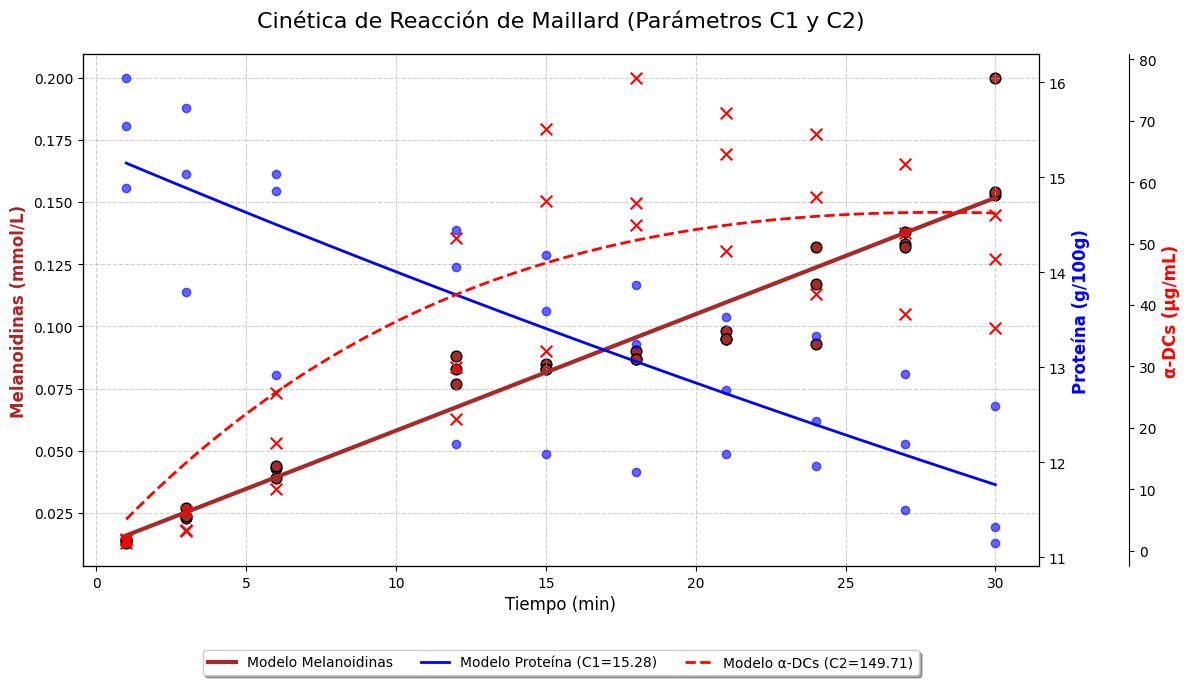

In [3]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# ================================
# 2. CARGA DE DATOS (COLAB)
# ================================
from google.colab import files
uploaded = files.upload()

file_name = None
for f_uploaded in uploaded.keys():
    if 'machine learning' in f_uploaded.lower():
        file_name = f_uploaded
        break

if file_name is None:
    raise FileNotFoundError("Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'.")

df_raw = pd.read_excel(file_name, skiprows=4)

# ================================
# 3. EXTRACCIÓN DE DATOS (SOLO 200°C)
# ================================
try:
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 2], errors='coerce')
    melanoidinas_obs = pd.to_numeric(df_raw.iloc[:, 4], errors='coerce')
    proteina_obs = pd.to_numeric(df_raw.iloc[:, 6], errors='coerce')

    mask = tiempos.notna() & dcs_obs.notna() & melanoidinas_obs.notna() & proteina_obs.notna()

    tiempos = tiempos[mask].values
    dcs_obs = dcs_obs[mask].values
    melanoidinas_obs = melanoidinas_obs[mask].values
    proteina_obs = proteina_obs[mask].values

    print(f"✅ Datos de 200°C extraídos con éxito ({len(tiempos)} puntos).")
except Exception as e:
    print(f"❌ Error al extraer columnas: {e}")

# ================================
# 4. MODELOS CINÉTICOS (Nomenclatura C1, C2)
# ================================
def modelo_proteinas(t, kp, C1):
    """C1 reemplaza a P0"""
    return C1 * np.exp(kp * t)

def modelo_alpha_dcs(t, kf, kd, C2):
    """C2 reemplaza a C0"""
    return (kf * C2 / (kd - kf)) * (np.exp(-kf * t) - np.exp(-kd * t))

def modelo_melanoidinas(t, km, M0):
    return M0 + km * t

# ================================
# 5. AJUSTE DE MODELOS
# ================================
try:
    # Ajuste para Proteínas (C1)
    popt_p, _ = curve_fit(modelo_proteinas, tiempos, proteina_obs, p0=[0.01, proteina_obs[0]])

    # Ajuste para alpha-DCs (C2)
    popt_d, _ = curve_fit(modelo_alpha_dcs, tiempos, dcs_obs, p0=[0.1, 0.05, max(dcs_obs)])

    # Ajuste para Melanoidinas
    popt_m, _ = curve_fit(modelo_melanoidinas, tiempos, melanoidinas_obs, p0=[0.01, melanoidinas_obs[0]])

    print("\n📊 Parámetros ajustados (Nomenclatura C1, C2):")
    print(f"Proteína: kp={popt_p[0]:.4f}, C1={popt_p[1]:.4f}")
    print(f"α-DCs:    kf={popt_d[0]:.4f}, kd={popt_d[1]:.4f}, C2={popt_d[2]:.4f}")
    print(f"Melanoidinas: km={popt_m[0]:.4f}, M0={popt_m[1]:.4f}")
except Exception as e:
    print(f"⚠️ Error en el ajuste: {e}")

# ================================
# 6. VISUALIZACIÓN
# ================================
if len(tiempos) > 0:
    t_smooth = np.linspace(min(tiempos), max(tiempos), 100)
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje 1: Melanoidinas
    line1 = ax1.plot(t_smooth, modelo_melanoidinas(t_smooth, *popt_m), color='brown', lw=3, label='Modelo Melanoidinas')
    ax1.scatter(tiempos, melanoidinas_obs, color='brown', s=60, edgecolors='black')
    ax1.set_xlabel('Tiempo (min)', fontsize=12)
    ax1.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12, fontweight='bold')

    # Eje 2: Proteína (Usa C1)
    ax2 = ax1.twinx()
    line2 = ax2.plot(t_smooth, modelo_proteinas(t_smooth, *popt_p), color='blue', lw=2, label=f'Modelo Proteína (C1={popt_p[1]:.2f})')
    ax2.scatter(tiempos, proteina_obs, color='blue', alpha=0.6)
    ax2.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12, fontweight='bold')

    # Eje 3: α-DCs (Usa C2)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 65))
    line3 = ax3.plot(t_smooth, modelo_alpha_dcs(t_smooth, *popt_d), color='red', linestyle='--', lw=2, label=f'Modelo α-DCs (C2={popt_d[2]:.2f})')
    ax3.scatter(tiempos, dcs_obs, color='red', marker='x', s=70)
    ax3.set_ylabel('α-DCs (μg/mL)', color='red', fontsize=12, fontweight='bold')

    # Leyenda unificada
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

    plt.title('Cinética de Reacción de Maillard (Parámetros C1 y C2)', fontsize=16, pad=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()

Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético (1).xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning (1).xlsx
✅ Archivo de constantes 'Datos para entrenar el modelo constantes de velocidad para el modelo cinético (1).xlsx' cargado con éxito.
✅ Datos de 220°C extraídos con éxito (30 puntos encontrados).

📊 Parámetros ajustados para 220°C:
Proteína: kp=-0.0103, C1=15.3076
α-DCs:    kf=0.0576, kd=0.0576, C2=132.0661
Melanoidinas: km=0.0064, M0=0.0019


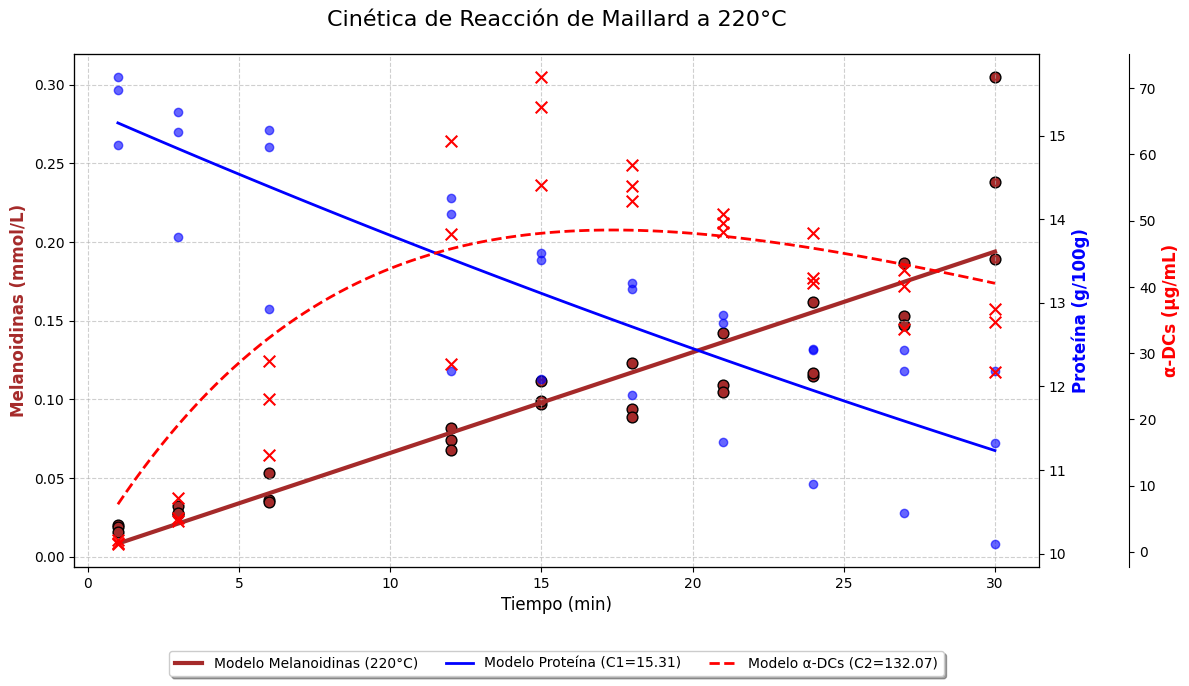

In [8]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ================================
# 2. CARGA DE DATOS (COLAB)
# ================================
from google.colab import files
uploaded = files.upload()

file_data = None
file_params = None

# Identificamos los dos archivos por su nombre
for f_name in uploaded.keys():
    lower_name = f_name.lower()
    if 'machine learning' in lower_name:
        file_data = f_name
    elif 'constantes' in lower_name or 'cinético' in lower_name:
        file_params = f_name

if file_data is None:
    raise FileNotFoundError("Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'.")

# Cargamos el archivo principal de datos experimentales
df_raw = pd.read_excel(file_data, skiprows=4)

# Cargamos el archivo de constantes para referencia (opcional para el ajuste)
if file_params:
    df_constantes = pd.read_excel(file_params)
    print(f"✅ Archivo de constantes '{file_params}' cargado con éxito.")

# ================================
# 3. EXTRACCIÓN DE DATOS (220°C)
# ================================
try:
    # Ajuste de índices para 220°C según la estructura del Excel:
    # Tiempo: Columna 1 (B)
    # α-DCs 220°C: Columna 8 (I)
    # Melanoidinas 220°C: Columna 10 (K)
    # Proteínas 220°C: Columna 12 (M)
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 8], errors='coerce')
    melanoidinas_obs = pd.to_numeric(df_raw.iloc[:, 10], errors='coerce')
    proteina_obs = pd.to_numeric(df_raw.iloc[:, 12], errors='coerce')

    # Filtramos valores nulos
    mask = tiempos.notna() & dcs_obs.notna() & melanoidinas_obs.notna() & proteina_obs.notna()

    tiempos = tiempos[mask].values
    dcs_obs = dcs_obs[mask].values
    melanoidinas_obs = melanoidinas_obs[mask].values
    proteina_obs = proteina_obs[mask].values

    print(f"✅ Datos de 220°C extraídos con éxito ({len(tiempos)} puntos encontrados).")
except Exception as e:
    print(f"❌ Error al extraer columnas: {e}")

# ================================
# 4. MODELOS CINÉTICOS (Nomenclatura C1, C2)
# ================================
def modelo_proteinas(t, kp, C1):
    """C1 representa la concentración inicial"""
    return C1 * np.exp(kp * t)

def modelo_alpha_dcs(t, kf, kd, C2):
    """C2 representa el precursor inicial"""
    return (kf * C2 / (kd - kf)) * (np.exp(-kf * t) - np.exp(-kd * t))

def modelo_melanoidinas(t, km, M0):
    """Crecimiento lineal de melanoidinas"""
    return M0 + km * t

# ================================
# 5. AJUSTE DE MODELOS
# ================================
try:
    # Ajuste para Proteínas (C1) - kp suele ser negativo porque disminuye
    popt_p, _ = curve_fit(modelo_proteinas, tiempos, proteina_obs, p0=[-0.01, proteina_obs[0]])

    # Ajuste para alpha-DCs (C2) - p0 ajustado para la mayor velocidad a 220°C
    popt_d, _ = curve_fit(modelo_alpha_dcs, tiempos, dcs_obs, p0=[0.2, 0.05, max(dcs_obs)*2])

    # Ajuste para Melanoidinas
    popt_m, _ = curve_fit(modelo_melanoidinas, tiempos, melanoidinas_obs, p0=[0.01, melanoidinas_obs[0]])

    print("\n📊 Parámetros ajustados para 220°C:")
    print(f"Proteína: kp={popt_p[0]:.4f}, C1={popt_p[1]:.4f}")
    print(f"α-DCs:    kf={popt_d[0]:.4f}, kd={popt_d[1]:.4f}, C2={popt_d[2]:.4f}")
    print(f"Melanoidinas: km={popt_m[0]:.4f}, M0={popt_m[1]:.4f}")
except Exception as e:
    print(f"⚠️ Error en el ajuste: {e}")

# ================================
# 6. VISUALIZACIÓN
# ================================
if len(tiempos) > 0:
    t_smooth = np.linspace(min(tiempos), max(tiempos), 100)
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje 1: Melanoidinas (Izquierda)
    line1 = ax1.plot(t_smooth, modelo_melanoidinas(t_smooth, *popt_m), color='brown', lw=3, label='Modelo Melanoidinas (220°C)')
    ax1.scatter(tiempos, melanoidinas_obs, color='brown', s=60, edgecolors='black', label='Obs. Melanoidinas')
    ax1.set_xlabel('Tiempo (min)', fontsize=12)
    ax1.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12, fontweight='bold')

    # Eje 2: Proteína (Derecha 1)
    ax2 = ax1.twinx()
    line2 = ax2.plot(t_smooth, modelo_proteinas(t_smooth, *popt_p), color='blue', lw=2, label=f'Modelo Proteína (C1={popt_p[1]:.2f})')
    ax2.scatter(tiempos, proteina_obs, color='blue', alpha=0.6, label='Obs. Proteína')
    ax2.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12, fontweight='bold')

    # Eje 3: α-DCs (Derecha 2 - Desplazado)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 65))
    line3 = ax3.plot(t_smooth, modelo_alpha_dcs(t_smooth, *popt_d), color='red', linestyle='--', lw=2, label=f'Modelo α-DCs (C2={popt_d[2]:.2f})')
    ax3.scatter(tiempos, dcs_obs, color='red', marker='x', s=70, label='Obs. α-DCs')
    ax3.set_ylabel('α-DCs (μg/mL)', color='red', fontsize=12, fontweight='bold')

    # Configuración de leyenda
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

    plt.title('Cinética de Reacción de Maillard a 220°C', fontsize=16, pad=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()

Saving Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx to Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx
Saving Datos para entrenar el modelo de machine learning.xlsx to Datos para entrenar el modelo de machine learning.xlsx
✅ Datos de 240°C extraídos con éxito (30 puntos encontrados).

📊 Parámetros ajustados para 240°C:
Proteína:     kp=-0.0102, C1=14.6388
α-DCs:        kf=0.0832, kd=0.0832, C2=127.6233
Melanoidinas: km=0.0099, M0=0.0060


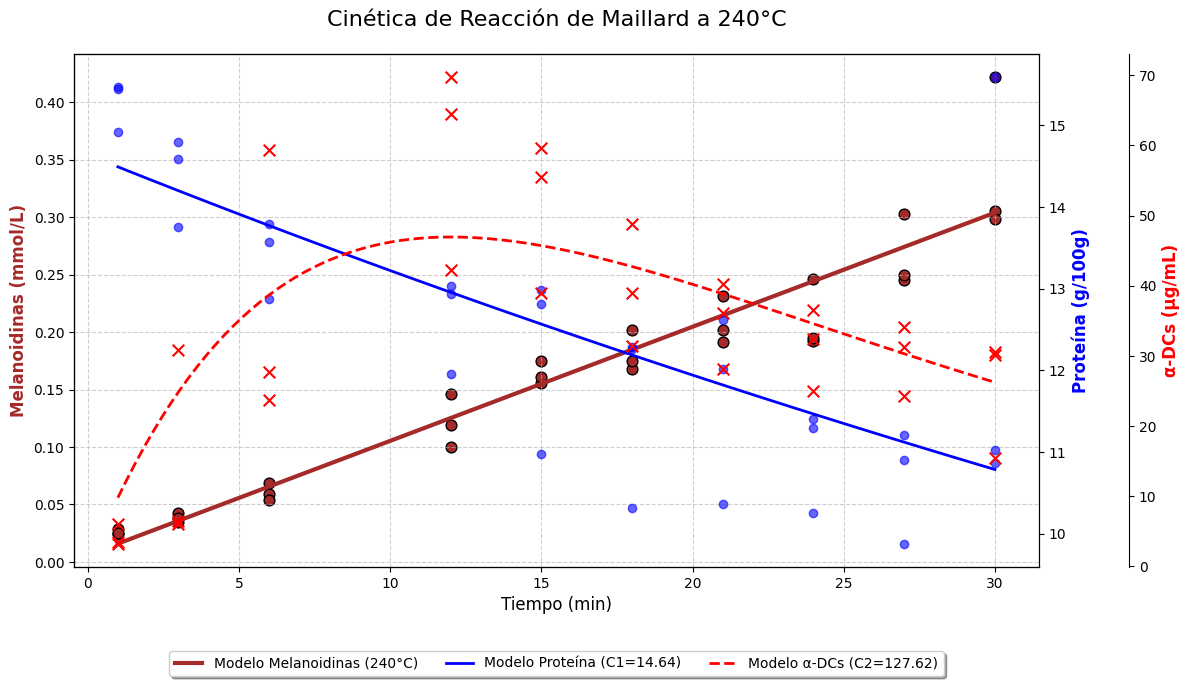

In [10]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ================================
# 2. CARGA DE DATOS (COLAB)
# ================================
from google.colab import files
uploaded = files.upload()

file_data = None
file_params = None

for f_name in uploaded.keys():
    lower_name = f_name.lower()
    if 'machine learning' in lower_name:
        file_data = f_name
    elif 'constantes' in lower_name or 'cinético' in lower_name:
        file_params = f_name

if file_data is None:
    raise FileNotFoundError("Por favor, sube el archivo 'Datos para entrenar el modelo de machine learning.xlsx'.")

df_raw = pd.read_excel(file_data, skiprows=4)

# ================================
# 3. EXTRACCIÓN DE DATOS (240 °C)
# ================================
try:
    # Ajuste de índices para 240°C (Último bloque del Excel):
    # Tiempo: Columna 1 (B)
    # α-DCs 240°C: Columna 14 (O)
    # Melanoidinas 240°C: Columna 16 (Q)
    # Proteínas 240°C: Columna 18 (S)
    tiempos = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
    dcs_obs = pd.to_numeric(df_raw.iloc[:, 14], errors='coerce')
    melanoidinas_obs = pd.to_numeric(df_raw.iloc[:, 16], errors='coerce')
    proteina_obs = pd.to_numeric(df_raw.iloc[:, 18], errors='coerce')

    mask = tiempos.notna() & dcs_obs.notna() & melanoidinas_obs.notna() & proteina_obs.notna()

    tiempos = tiempos[mask].values
    dcs_obs = dcs_obs[mask].values
    melanoidinas_obs = melanoidinas_obs[mask].values
    proteina_obs = proteina_obs[mask].values

    print(f"✅ Datos de 240°C extraídos con éxito ({len(tiempos)} puntos encontrados).")
except Exception as e:
    print(f"❌ Error al extraer columnas: {e}")

# ================================
# 4. MODELOS CINÉTICOS (Corregidos)
# ================================
def modelo_proteinas(t, kp, C1):
    return C1 * np.exp(kp * t)

def modelo_alpha_dcs(t, kf, kd, C2):
    # Protección contra división por cero si kf == kd
    diff = kd - kf
    if abs(diff) < 1e-7: diff = 1e-7
    return (kf * C2 / diff) * (np.exp(-kf * t) - np.exp(-kd * t))

def modelo_melanoidinas(t, km, M0):
    return M0 + km * t

# ================================
# 5. AJUSTE DE MODELOS
# ================================
try:
    # Ajuste para Proteínas
    popt_p, _ = curve_fit(modelo_proteinas, tiempos, proteina_obs, p0=[-0.02, 15.5])

    # Ajuste para alpha-DCs (p0 ajustado para la agresividad de 240°C)
    popt_d, _ = curve_fit(modelo_alpha_dcs, tiempos, dcs_obs, p0=[0.3, 0.1, max(dcs_obs)*2])

    # Ajuste para Melanoidinas
    popt_m, _ = curve_fit(modelo_melanoidinas, tiempos, melanoidinas_obs, p0=[0.05, 0.01])

    print("\n📊 Parámetros ajustados para 240°C:")
    print(f"Proteína:     kp={popt_p[0]:.4f}, C1={popt_p[1]:.4f}")
    print(f"α-DCs:        kf={popt_d[0]:.4f}, kd={popt_d[1]:.4f}, C2={popt_d[2]:.4f}")
    print(f"Melanoidinas: km={popt_m[0]:.4f}, M0={popt_m[1]:.4f}")
except Exception as e:
    print(f"⚠️ Error en el ajuste: {e}")

# ================================
# 6. VISUALIZACIÓN
# ================================
if len(tiempos) > 0:
    t_smooth = np.linspace(min(tiempos), max(tiempos), 100)
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje 1: Melanoidinas (Marrón)
    line1 = ax1.plot(t_smooth, modelo_melanoidinas(t_smooth, *popt_m), color='brown', lw=3, label='Modelo Melanoidinas (240°C)')
    ax1.scatter(tiempos, melanoidinas_obs, color='brown', s=60, edgecolors='black', label='Obs. Melanoidinas')
    ax1.set_xlabel('Tiempo (min)', fontsize=12)
    ax1.set_ylabel('Melanoidinas (mmol/L)', color='brown', fontsize=12, fontweight='bold')

    # Eje 2: Proteína (Azul)
    ax2 = ax1.twinx()
    line2 = ax2.plot(t_smooth, modelo_proteinas(t_smooth, *popt_p), color='blue', lw=2, label=f'Modelo Proteína (C1={popt_p[1]:.2f})')
    ax2.scatter(tiempos, proteina_obs, color='blue', alpha=0.6, label='Obs. Proteína')
    ax2.set_ylabel('Proteína (g/100g)', color='blue', fontsize=12, fontweight='bold')

    # Eje 3: α-DCs (Rojo)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 65))
    line3 = ax3.plot(t_smooth, modelo_alpha_dcs(t_smooth, *popt_d), color='red', linestyle='--', lw=2, label=f'Modelo α-DCs (C2={popt_d[2]:.2f})')
    ax3.scatter(tiempos, dcs_obs, color='red', marker='x', s=70, label='Obs. α-DCs')
    ax3.set_ylabel('α-DCs (μg/mL)', color='red', fontsize=12, fontweight='bold')

    # Configuración de leyenda
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

    plt.title('Cinética de Reacción de Maillard a 240°C', fontsize=16, pad=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    fig.tight_layout()
    plt.show()